# **Practical assignment for Topic 4**

In this assigmnet, use the following data for the **Tasks 1 and 2**:

In [1]:
import numpy as np

In [2]:
X = np.array([-3.00, -2.54, -2.08, -1.62, -1.15, -0.69, -0.23,  0.23,  0.69,  1.15,  1.62,  2.08,  2.54,  3.00]).reshape(14, 1)
y = np.array([ 2.60,  2.81,  3.49,  4.08,  3.30,  3.43,  4.59,  4.65,  4.79,  6.45,  7.58,  9.78, 12.98, 15.49]).reshape(14, 1)

and use the following data for the **Task 3**:

In [3]:
X = np.array([-3.00, -2.79, -2.59 , -2.38, -2.17,
       -1.97, -1.76, -1.55, -1.34, -1.14,
       -0.93, -0.72, -0.52, -0.31, -0.10,
        0.10,  0.31,  0.52,  0.72,  0.93,
        1.14,  1.34,  1.55,  1.76,  1.97,
        2.17,  2.38,  2.59,  2.79,  3.00]).reshape(30, 1)
y = np.array([2.60,  2.55,  3.16,  3.76,  3.00,
        3.10,  4.07,  3.72,  3.14,  3.69,
        3.24,  3.30,  3.74,  2.79,  3.04,
        3.83,  3.87,  4.86,  4.64,  4.87,
        6.87,  6.68,  7.59,  7.72,  9.15,
       10.60, 11.22, 13.38, 14.44, 16.30]).reshape(30, 1)

*Note that the two datasets were created using exactly the same noisy function. The second dataset is just larger.*

Your assignment consists of the following tasks:

1. Create a total of eight polynomial models with degrees from 1 to 8. Compute and print training MSE and validation MSE values for each of them. Validation MSE should be computed using LOOCV (use the scikit-learn solution that we used in the lecture). Draw a plot with two curves analogous to the plot shown on slide 9 from the lecture (horizontal axis is the number of model's parameters in your case). Add a legend so that it is clear which curve is which. Don't worry if the curves are slightly more noisy compared to those on the slide.<br>
Create a separate text cell and explain the plot. What can you see in it, what does it mean, and what conclusions can you make from it? Which model do you recommend for this dataset?

2. Draw another plot, this time showing all datapoints of the given dataset together with the curves of all eight polynomials with degrees from 1 to 8. Each curve should be in a different color. Add a legend so that it is clear which curve is which.<br>
Create a separate text cell and briefly explain the plot. What can you see in it?

3. Show learning curves of your eight models (a separate plot for each model). Use the same vertical axis range for all eight plots so that all important parts are clearly visible and the plots are easily comparable. Do this task using the scikit-learn solutions that we used in the lecture.<br>
Now look at the plots and in a separate text cell write a short analysis of them. What useful conclusions can you make regarding overfitting, data amount, the best model, and data noise level?

*While doing the tasks you are allowed to use only those function libraries and only those scikit-learn functions that were already used in the lectures so far.*

**After the tasks are done, submit this file. Do not clear it's output - all print-outs and figures should be left in the file. All your code should be fully runnable in the order of appearance and it should produce exactly the same output that is present in your print-outs and figures you left in the file.**

---
# **Task 1**

1. Create a total of eight polynomial models with degrees from 1 to 8. Compute and print training MSE and validation MSE values for each of them. Validation MSE should be computed using LOOCV (use the scikit-learn solution that we used in the lecture). Draw a plot with two curves analogous to the plot shown on slide 9 from the lecture (horizontal axis is the number of model's parameters in your case). Add a legend so that it is clear which curve is which. Don't worry if the curves are slightly more noisy compared to those on the slide.

Degree | Parameters | Training MSE | Validation MSE (LOOCV)
------------------------------------------------------
     1 |          2 |       4.0178 |                 4.7930
     2 |          3 |       0.6352 |                 0.8700
     3 |          4 |       0.1570 |                 0.1980
     4 |          5 |       0.1448 |                 0.1965
     5 |          6 |       0.1415 |                 0.2194
     6 |          7 |       0.1344 |                 0.2231
     7 |          8 |       0.1312 |                 0.2152
     8 |          9 |       0.1257 |                 0.3394


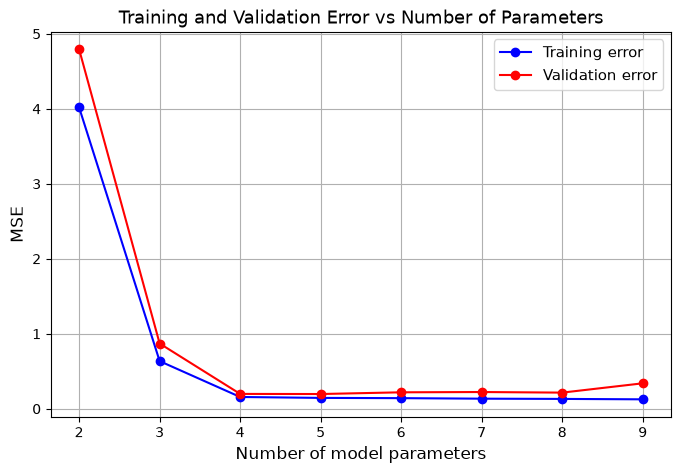

In [5]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import LeaveOneOut, cross_val_predict

degrees = list(range(1, 9))
num_params = [d + 1 for d in degrees]
train_errors = []
val_errors = []

print("Degree | Parameters | Training MSE | Validation MSE (LOOCV)")
print("-" * 54)

for degree in degrees:
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly_features.fit_transform(X)

    lin_reg = LinearRegression()
    lin_reg.fit(X_poly, y)
    y_pred_train = lin_reg.predict(X_poly)
    train_mse = mean_squared_error(y, y_pred_train)
    train_errors.append(train_mse)

    y_pred_val = cross_val_predict(LinearRegression(), X_poly, y, cv=LeaveOneOut())
    val_mse = mean_squared_error(y, y_pred_val)
    val_errors.append(val_mse)
    
    print(f"{degree:6d} | {degree+1:10d} | {train_mse:12.4f} | {val_mse:22.4f}")

plt.figure(figsize=(8, 5))
plt.plot(num_params, train_errors, 'b-o', label='Training error')
plt.plot(num_params, val_errors, 'r-o', label='Validation error')
plt.xlabel("Number of model parameters", fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Training and Validation Error vs Number of Parameters', fontsize=13)
plt.xticks(num_params)
plt.grid(True)
plt.legend(fontsize=11)
plt.show()

---
# **Task 2**

2. Draw another plot, this time showing all datapoints of the given dataset together with the curves of all eight polynomials with degrees from 1 to 8. Each curve should be in a different color. Add a legend so that it is clear which curve is which.

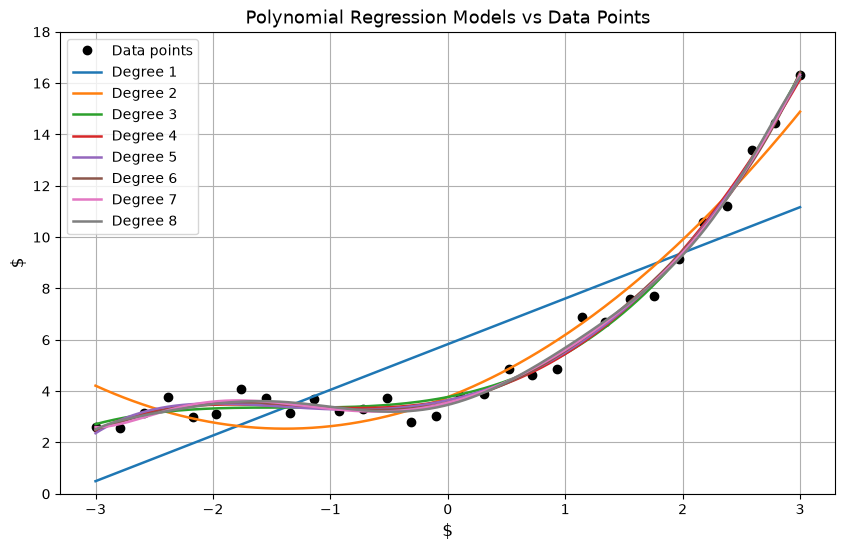

In [7]:
plt.figure(figsize=(10, 6))

plt.plot(X, y, 'ko', markersize=6, label='Data points')

X_plot = np.linspace(np.min(X), np.max(X), 300).reshape(-1, 1)

for degree in range(1, 9):
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly_features.fit_transform(X)
    X_plot_poly = poly_features.transform(X_plot)
    
    lin_reg = LinearRegression()
    lin_reg.fit(X_poly, y)
    y_plot = lin_reg.predict(X_plot_poly)
    
    plt.plot(X_plot, y_plot, label=f'Degree {degree}', linewidth=1.8)

plt.xlabel('$', fontsize=12)
plt.ylabel('$', fontsize=12)
plt.title('Polynomial Regression Models vs Data Points', fontsize=13)
plt.ylim(0, 18)
plt.grid(True)
plt.legend(loc='upper left', fontsize=10)
plt.show()

---
# **Task 3**

3. Show learning curves of your eight models (a separate plot for each model). Use the same vertical axis range for all eight plots so that all important parts are clearly visible and the plots are easily comparable. Do this task using the scikit-learn solutions that we used in the lecture.

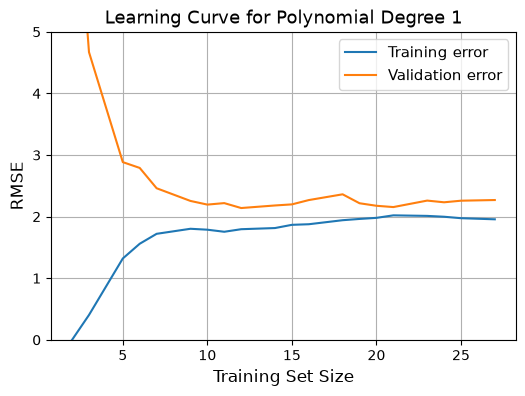

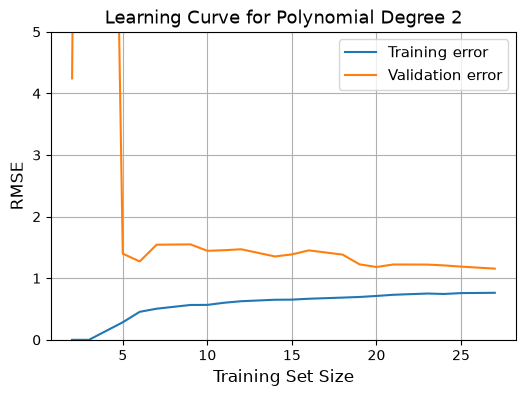

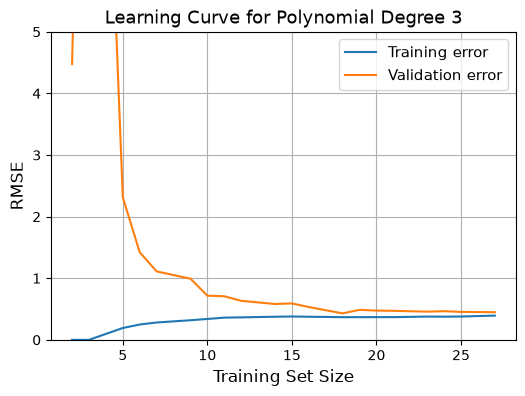

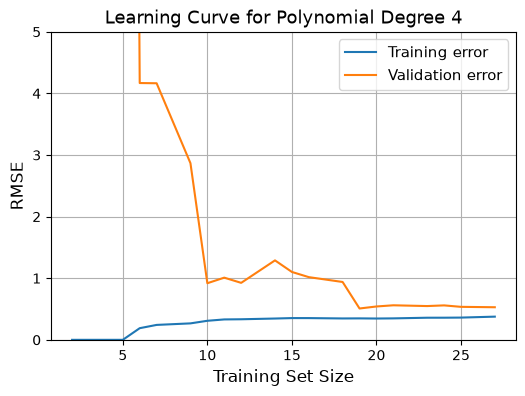

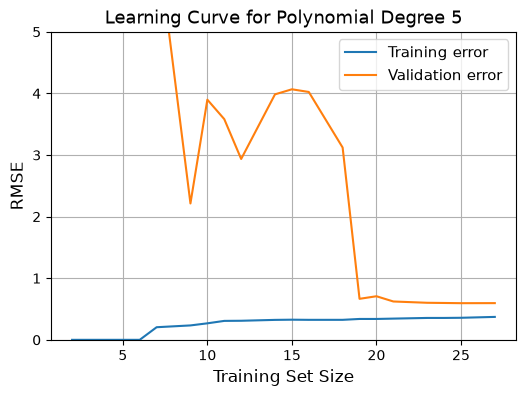

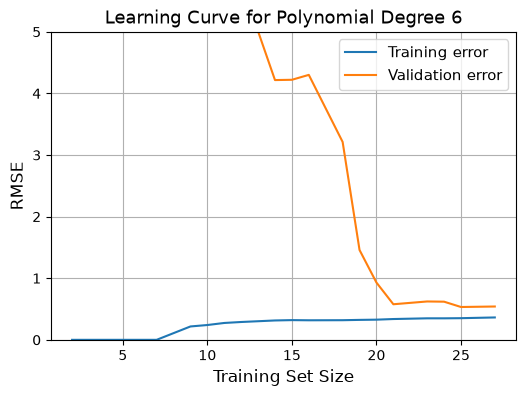

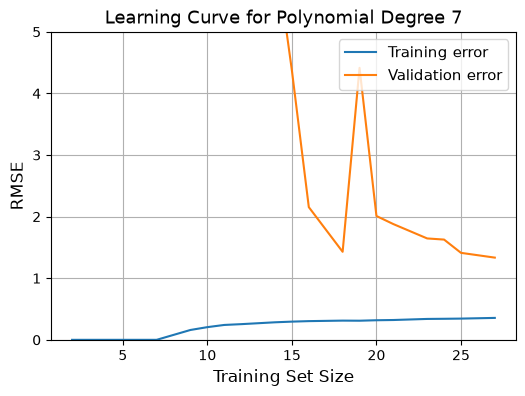

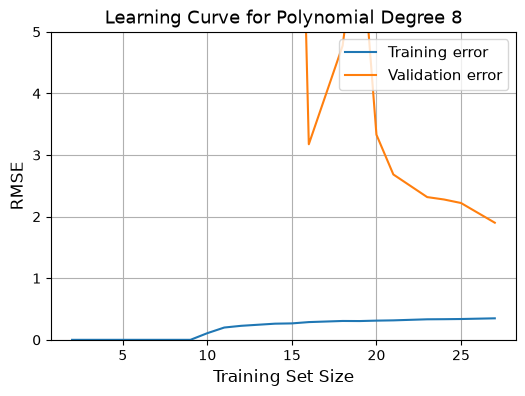

In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve

def PolynomialRegression(degree, **kwargs):
    return make_pipeline(PolynomialFeatures(degree, include_bias=False), LinearRegression(**kwargs))

def plot_learning_curve(degree):
    train_sizes = np.linspace(0.1, 1.0, 20)
    N_train, val_train, val_test = learning_curve(
        PolynomialRegression(degree), X, y, train_sizes=train_sizes,
        cv=10, shuffle=True, random_state=1, scoring='neg_root_mean_squared_error')
    
    plt.figure(figsize=(6, 4))
    plt.plot(N_train, -val_train.mean(axis=1), label='Training error')
    plt.plot(N_train, -val_test.mean(axis=1), label='Validation error')
    plt.xlabel('Training Set Size', fontsize=12)
    plt.ylabel('RMSE', fontsize=12)
    plt.title(f'Learning Curve for Polynomial Degree {degree}', fontsize=13)
    plt.ylim(0, 5.0)
    plt.grid(True)
    plt.legend(loc='upper right', fontsize=11)
    plt.show()

for degree in range(1, 9):
    plot_learning_curve(degree)

Assignee: Jakob Benedikt Wilmesmeier